In [1]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.optimize import minimize
# from scipy.optimize import Bounds
from scipy.linalg import cho_solve
# from pyDOE import lhs
import scipy.optimize as opt
import random
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib
from sklearn.metrics import mean_squared_error
from scipy.linalg import cho_solve
import pandas as pd

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
Benedict_data = np.loadtxt('Benedict_Diamond.txt')
degree = 3

In [3]:
# idx = random.sample(range(Benedict_data.shape[0]-1), 10)
# idx
idx = [13, 42, 57, 33, 75, 52, 41, 9, 43, 69, 4, 82, 34, 93, 27, 63, 1, 40, 79,18]   # sample of 20 points

In [4]:
data = Benedict_data[idx,:]


In [5]:


X = data[:,0:2]                                     # input Volume-Temperature
y1 = data[:,2].reshape(-1,1)                        # output pressure
y2 = data[:,3].reshape(-1,1)                        # output energy
y3 = y2 + 8.9431 + 0.5 * (X[:,0].reshape(-1,1) - 5.6648) * (y1 + 12)*((1e-2)/1.6)       # Hugoniot



# y = np.concatenate((y1,y2))

In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X)
X = scaler.transform(X)


scaler1 = MinMaxScaler()
y_norm = scaler1.fit_transform(np.hstack((y1,y2)))
y = np.concatenate((y_norm[:,0], y_norm[:,1]))
y = y.reshape(-1,1)

scaler2 = MinMaxScaler()
H = scaler2.fit_transform(y3)


In [7]:
def test(X, n_test):
    X1 = np.linspace(X[:,0].max(), X[:,0].min(), n_test)
    X2 = np.linspace(X[:,1].min(), X[:,1].max(), n_test)
    X1P, X2P = np.meshgrid(X1, X2)
    X1E, X2E = np.meshgrid(X2, X1)
    X_testP = np.hstack((X1P.reshape(-1,1), X2P.reshape(-1,1)))
    X_testE = np.hstack((X2E.reshape(-1,1), X1E.reshape(-1,1)))
    return X_testP, X_testE


/var/folders/vd/pr68_4js7vnf535141p_blwc0000gn/T/ipykernel_93995/1063437389.py:3: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 11


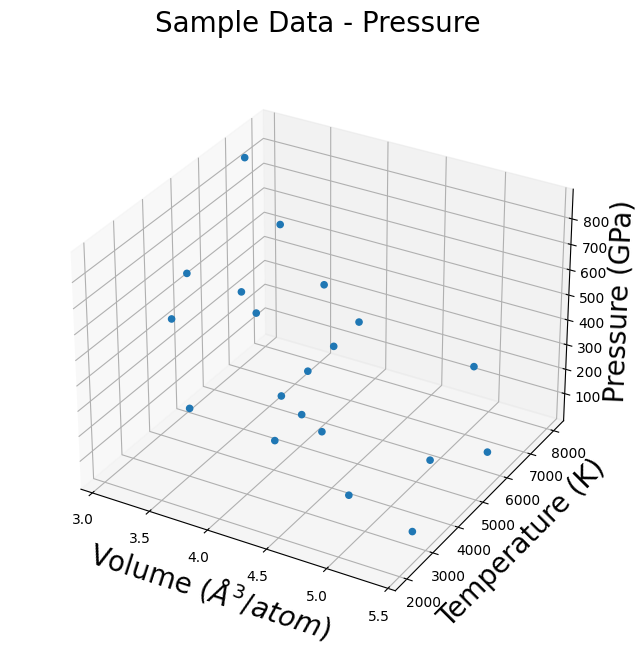

In [8]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
ax.dist = 11
ax.scatter(data[:,0], data[:,1], y1, alpha=1)
ax.set_zlabel('Pressure (GPa)',fontsize=20)
ax.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=20, labelpad=8 )
ax.set_ylabel('Temperature (K)', fontsize=20, labelpad=8)

ax.set_title('Sample Data - Pressure', fontsize = 20)
plt.show()

/var/folders/vd/pr68_4js7vnf535141p_blwc0000gn/T/ipykernel_93995/3092738714.py:3: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 11


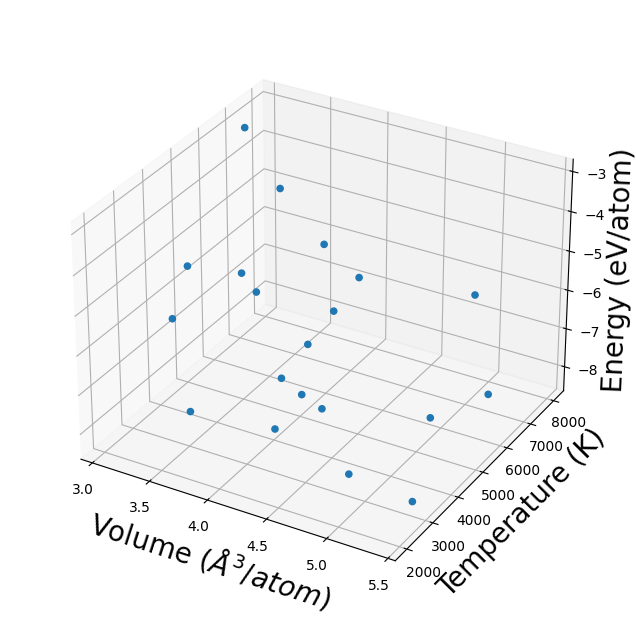

In [9]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
ax.dist = 11
ax.scatter(data[:,0], data[:,1], y2, alpha=1)
ax.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=20 , labelpad=8)
ax.set_ylabel('Temperature (K)', fontsize=20, labelpad=8)
ax.set_zlabel('Energy (eV/atom)',fontsize=20)
# ax.set_title('Sample Data - Energy', fontsize = 20)
plt.show()

In [10]:
def poly_regression(x_train, y_train, x_test, degree):
    
    poly = PolynomialFeatures(degree)
    
    y_P = y_train[:x_train.shape[0]]
    y_E = y_train[x_train.shape[0]:]
    
    poly_train = poly.fit_transform(x_train)
    poly_test = poly.fit_transform(x_test)
    
    reg_P = LinearRegression().fit(poly_train, y_P)
    reg_E = LinearRegression().fit(poly_train, y_E)
    
    mu_P = reg_P.predict(poly_train)
    mu_E = reg_E.predict(poly_train)
    
    mu_test_P = reg_P.predict(poly_test)
    mu_test_E = reg_E.predict(poly_test)
    
    mu_regression = np.concatenate((mu_P,mu_E))      
    mu_test_regression = np.concatenate((mu_test_P,mu_test_E))
    
    return mu_regression, mu_test_regression



In [11]:
X_test,_ = test(X, n_test = 50)                # test points

In [12]:
mu_regression, mu_test_regression = poly_regression(X, y, X_test, degree)

In [13]:
rmse_Pressure = np.sqrt(mean_squared_error(y[:X.shape[0]], mu_regression[:y1.shape[0]]))
rmse_Energy = np.sqrt(mean_squared_error(y[X.shape[0]:], mu_regression[y2.shape[0]:]))
print(rmse_Pressure)
print(rmse_Energy)

0.0032875312993412738
0.002257758946240762


In [14]:
def gradientFunction(x_train, y_train, n_test):
    
    X_testP, X_testE = test(x_train, n_test)
    _ , mu_test_regression_P = poly_regression(x_train, y_train, X_testP, degree)
    _, mu_test_regression_E = poly_regression(x_train, y_train, X_testE, degree)
    
    
    y_pred_P = np.squeeze(mu_test_regression_P[:X_testP.shape[0]])
    y_pred_E = np.squeeze(mu_test_regression_E[X_testE.shape[0]:])
    gradP_V = np.gradient(y_pred_P, X_testP[:,0])
    gradE_T = np.gradient(y_pred_E, X_testE[:,1])
    
    return gradP_V, gradE_T

In [15]:
def poly_regression_prime(x_train, x_virtual, degree):
    
    gradP_V, gradE_T = gradientFunction(X, y, n_test = 30)
    X_testP, X_testE = test(x_train, n_test= 30)
    
    poly = PolynomialFeatures(degree)
    
    y_P = gradP_V.reshape(-1,1)
    y_E = gradE_T.reshape(-1,1)
    
    poly_train_P = poly.fit_transform(X_testP)
    poly_train_E = poly.fit_transform(X_testE)
    
    poly_test = poly.fit_transform(x_virtual)
    
    reg_P = LinearRegression().fit(poly_train_P, y_P)
    reg_E = LinearRegression().fit(poly_train_E, y_E)
    
    
    mu_virtual_P = reg_P.predict(poly_test)
    mu_virtual_E = reg_E.predict(poly_test)
    
         
    mu_virtual_regression = np.concatenate((mu_virtual_P,mu_virtual_E))
    
    return mu_virtual_regression



In [16]:
mu_virtual_regression = poly_regression_prime(X, X_test, degree=3)

In [17]:
def K11(x1, x2, l1, l2, sigma_f, sigma_n1):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (2*theta[0] - 4*theta[0]**2 * sq_diff_x[:,:,0])

    return K + np.eye(x1.shape[0],x2.shape[0]) * (sigma_n1)**2

In [18]:

def K22(x1, x2, l1, l2, sigma_f, sigma_n2):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    exp_term = np.exp(-np.sum(theta * sq_diff_x, axis=2))

    K = sigma_f**2 * (exp_term +
                      x1[:, 1][:, None] * exp_term * (2 * theta[1] * (x1[:, 1][:, None] - x2[:, 1][None, :])) +
                      x2[:, 1][None, :] * exp_term * (2 * theta[1] * (-x1[:, 1][:, None] + x2[:, 1][None, :])) +
                      x1[:, 1][:, None] * x2[:, 1][None, :] * exp_term * (2 * theta[1] - 4 * theta[1]**2 * sq_diff_x[:,:,1]))

    return K + np.eye(x1.shape[0],x2.shape[0]) * (sigma_n2)**2

In [19]:
def K21(x1, x2, l1, l2, sigma_f):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * (np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (2 * theta[0] * (-x1[:, 0][:, None] + x2[:, 0][None, :])) -
                      x1[:, 1][:, None] * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * theta[0] * theta[1] * (x1[:, 0][:, None] - x2[:, 0][None, :]) * (x1[:, 1][:, None] - x2[:, 1][None, :])))

    return K

In [20]:
def K12(x1, x2, l1, l2, sigma_f):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * (np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (2 * theta[0] * (x1[:, 0][:, None] - x2[:, 0][None, :])) -
                      x2[:, 1][None, :] * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * theta[0] * theta[1] * (x1[:, 0][:, None] - x2[:, 0][None, :]) * (x1[:, 1][:, None] - x2[:, 1][None, :])))

    return K

In [21]:
def Kblock(x1,x2,l1,l2,sigma_f, sigma_n1, sigma_n2):
    
    K = np.block([[K11(x1,x2,l1,l2,sigma_f, sigma_n1),K12(x1,x2,l1,l2,sigma_f)*0],[K21(x1,x2,l1,l2,sigma_f)*0, K22(x1,x2,l1,l2,sigma_f, sigma_n2)]])
    
    return K

In [22]:
def K11prime(x1, x2, l1, l2, sigma_f, sigma_n1):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * theta[0]**2 * (-8 * theta[0] * sq_diff_x[:,:,0] + (2 * theta[0] * sq_diff_x[:,:,0] - 1)**2 + 2))

    return K + np.eye(x1.shape[0],x2.shape[0]) * (sigma_n1)**2

In [23]:
def K12prime(x1, x2, l1, l2, sigma_f):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * x2[:, 1][None, :] * theta[0] * theta[1] * (2 * theta[0] * sq_diff_x[:,:,0] - 1) * (2 * theta[1] * sq_diff_x[:,:,1] - 1))

    return K

In [24]:
def K21prime(x1, x2, l1, l2, sigma_f):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * x1[:, 1][:, None] * theta[0] * theta[1] * (2 * theta[0] * sq_diff_x[:,:,0] - 1) * (2 * theta[1] * sq_diff_x[:,:,1] - 1))

    return K

In [25]:
def K22prime(x1, x2, l1, l2, sigma_f, sigma_n2):
    theta = np.array([1/(2*l1**2), 1/(2*l2**2)])

    diff_x = x1[:, None, :] - x2[None, :, :]
    sq_diff_x = diff_x ** 2

    K = sigma_f**2 * np.exp(-np.sum(theta * sq_diff_x, axis=2)) * (4 * x1[:, 1][:, None] * x2[:, 1][None, :] * theta[1]**2 * (-8 * theta[1] * sq_diff_x[:,:,1] + (2 * theta[1] * sq_diff_x[:,:,1] - 1)**2 + 2))

    return K + np.eye(x1.shape[0],x2.shape[0]) * (sigma_n2)**2

In [26]:
def Kblock_prime(x1,x2,l1,l2,sigma_f, sigma_n1, sigma_n2):
    
    K = np.block([[K11prime(x1,x2,l1,l2,sigma_f, sigma_n1),K12prime(x1,x2,l1,l2,sigma_f)*0],[K21prime(x1,x2,l1,l2,sigma_f)*0,K22prime(x1,x2,l1,l2,sigma_f, sigma_n2)]])
    
    return K

In [27]:
def mle(theta, x_train, y_train, mean_regression):
    
    l1,l2, sigma_f, sigma_n1, sigma_n2 = theta  
    n = x_train.shape[0]      
    K = Kblock(x_train, x_train, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2)   + np.eye(2*n)*1e-10
    L = np.linalg.cholesky(K)
    var = ((y_train - mean_regression).T @ (cho_solve((L, True), y_train - mean_regression))) 
    LnofDetK = 2*np.sum(np.log(np.abs(np.diag(L)))) 
    le = -(1/2)*var - 0.5*LnofDetK - (2*n/2)*np.log(2*np.pi)
    
    return -le.flatten()
        

In [28]:
def neglikelihood(theta):
    return mle(theta,X,y, mu_regression) 

In [29]:

def predict(theta, x_train, y_train, x_test):
    
    l1, l2, sigma_f, sigma_n1, sigma_n2 = np.power(10, theta)
    n = x_train.shape[0]
    mu_reg, mu_test_reg = poly_regression(x_train, y_train, x_test, degree)
    
    k12 = Kblock(x_train, x_test, l1, l2, sigma_f, sigma_n1, sigma_n2)
    k21 = Kblock(x_test, x_train, l1, l2, sigma_f, sigma_n1, sigma_n2)
    k22 = Kblock(x_test, x_test, l1, l2, sigma_f, sigma_n1, sigma_n2)
    K = Kblock(x_train, x_train, l1, l2, sigma_f, sigma_n1, sigma_n2) + np.eye(2 * n) * 1e-10
    L = np.linalg.cholesky(K)

    alpha = cho_solve((L, True), y_train - mu_reg)
    y_gp = mu_test_reg + k21 @ alpha
    varr = k22 - k21 @ cho_solve((L, True), k12)
    pred_var = np.diag(varr)
    pred_std = np.sqrt(pred_var)

    return y_gp.flatten(), pred_std.flatten()

In [30]:
def predict_prime(theta, x_train, y_train, x_test):
    
        l1,l2, sigma_f, sigma_n1, sigma_n2 = theta
        n = x_train.shape[0]
        y_traind = poly_regression_prime(x_train, x_train, 3)
        mu_test_reg = poly_regression_prime(x_train, x_test, degree)
        mu_reg = poly_regression_prime(x_train, x_train, degree)
        
        k12 = Kblock_prime(x_train, x_test, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2)  
        k21 = Kblock_prime(x_test, x_train, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2)
        k22 = Kblock_prime(x_test, x_test, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2) 
        K = Kblock_prime(x_train, x_train, 10**l1, 10**l2, 10**sigma_f, 10**sigma_n1, 10**sigma_n2) +  np.eye(2*n)*1e-10
        L = np.linalg.cholesky(K)

        y_gp = mu_test_reg + k21 @ (cho_solve((L, True), y_traind - mu_reg))
        # y_gp = mu_test_reg
        varr = k22 - k21 @ (cho_solve((L, True), k12))
        pred_var = varr.diagonal()
        pred_var1 = pred_var.flatten()
        pred_var1[pred_var1<0.0]=0.0

      
        return y_gp.flatten(), pred_var1

In [31]:
def opti():
    
        n = 10
        lb = np.array([-3.0,-3.0, -3.0, -10.0, -10.0])
        r= np.random.standard_normal(size=(n,5))
        x0 = r + lb
        optipar = np.zeros((n, 5))
        optifun = np.zeros((n, 1))
        for i in range(n):
            print(i)
            res= opt.fmin_cobyla(neglikelihood, x0[i,:].T, cons=[],args=(), consargs=None, rhobeg=1.0, rhoend=0.0001, maxfun=1000, disp=True, catol=0.0002)
            optipar[i,:] = res
            print(optipar[i,:])
            optifun[i,:] = neglikelihood(res)
            print(optifun[i,:])
        theta = optipar[np.argmin(optifun)]
        
        return theta

In [32]:
thetaopt = opti()


0
[-0.90384906 -1.31727013 -3.39469089 -9.1705452  -9.47906567]

   Normal return from subroutine COBYLA

   NFVALS =  204   F =-1.769612E+02    MAXCV = 0.000000E+00
   X =-9.038491E-01  -1.317270E+00  -3.394691E+00  -9.170545E+00  -9.479066E+00
[-176.96124776]
1
[ -0.90407855  -1.31747618  -3.39499524  -8.80150632 -11.16111747]

   Normal return from subroutine COBYLA

   NFVALS =  205   F =-1.769612E+02    MAXCV = 0.000000E+00
   X =-9.040785E-01  -1.317476E+00  -3.394995E+00  -8.801506E+00  -1.116112E+01
[-176.96123373]
2
[-0.90397753 -1.31724276 -3.39457371 -8.93582364 -8.47781071]

   Normal return from subroutine COBYLA

   NFVALS =  182   F =-1.769613E+02    MAXCV = 0.000000E+00
   X =-9.039775E-01  -1.317243E+00  -3.394574E+00  -8.935824E+00  -8.477811E+00
[-176.96125066]
3
[ -0.903787    -1.31692828  -3.39442134 -11.31998117  -8.182582  ]
   Normal return from subroutine COBYLA

   NFVALS =  214   F =-1.769613E+02    MAXCV = 0.000000E+00
   X =-9.037870E-01  -1.316928E+00  -3.

In [33]:
thetaopt 

array([ -0.90379096,  -1.3168637 ,  -3.39441348, -10.14317899,
       -11.13612955])

In [34]:
y_pred, y_std = predict(thetaopt, X, y, X_test)

In [35]:
X_testP, X_testE = test(X, n_test=50)          # test points

In [36]:
y_pred_P_prime, y_varr_P_prime = predict_prime(thetaopt, X, y, X_testP)
y_pred_E_prime, y_varr_E_prime = predict_prime(thetaopt, X, y, X_testE)

In [37]:
consP = y_pred_P_prime[:X_testP.shape[0]] + 1.96*np.sqrt(y_varr_P_prime[:X_testP.shape[0]])
consE = y_pred_E_prime[X_testE.shape[0]:] - 1.96*np.sqrt(y_varr_E_prime[X_testE.shape[0]:])
consP[consP>0].size, consE[consE<0].size

(0, 818)

In [38]:
y11 = y_pred[:X_test.shape[0]].reshape(-1,1)
y22 = y_pred[X_test.shape[0]:].reshape(-1,1)
y33 = y_std[:X_test.shape[0]].reshape(-1,1)
y44 = y_std[X_test.shape[0]:].reshape(-1,1)

In [39]:
y_mean = np.hstack((y11,y22))
y_ub = np.hstack((y11+y33, y22+y44))
y_lb = np.hstack((y11-y33, y22-y44))

In [40]:

y_mean1 = scaler1.inverse_transform(y_mean)
y_ub1 = scaler1.inverse_transform(y_ub)
y_lb1 = scaler1.inverse_transform(y_lb)
y_std1 = y_mean1 - y_lb1
y_std2 = y_ub1 - y_mean1

In [41]:
meanP = y_mean1[:,0]
meanE = y_mean1[:,1]
stdP =  y_std1[:,0]
stdE =  y_std1[:,1]

In [42]:
X_testP = scaler.inverse_transform(X_testP)
X_testE = scaler.inverse_transform(X_testE)

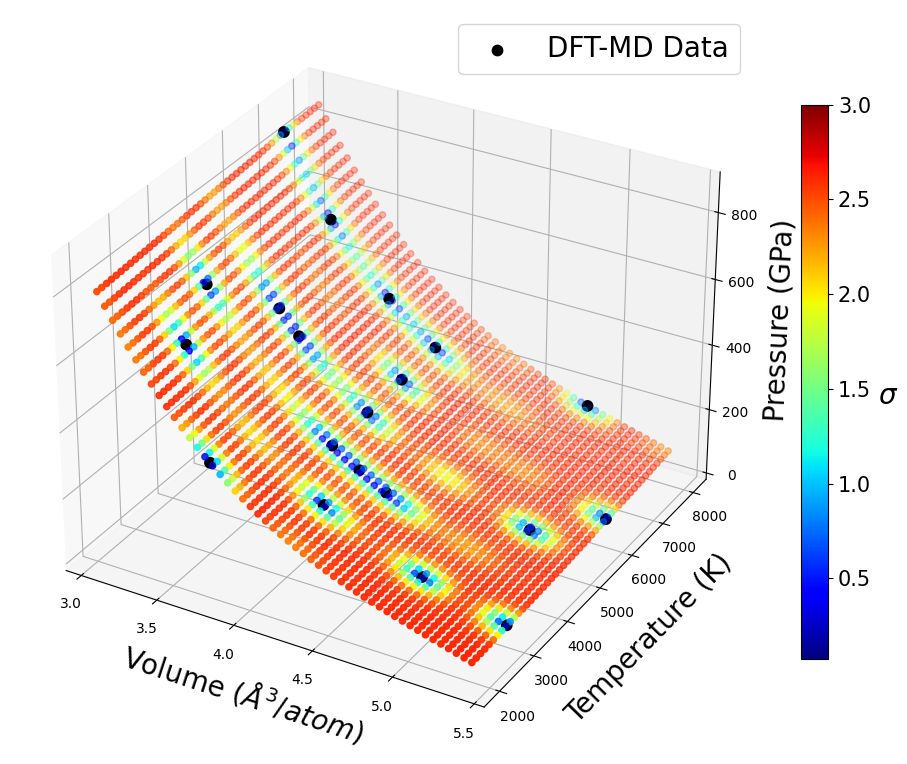

In [43]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(data[:,0], data[:,1], y1, alpha=1, marker="o", color="k", linewidths=4, label="Data")
p0 = ax.scatter(X_testP[:,0], X_testP[:,1], meanP ,c=stdP, cmap=plt.cm.jet,  vmax=3)
matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
ax.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=20, labelpad=8 )
ax.set_ylabel('Temperature (K)', fontsize=20, labelpad=12)
ax.set_zlabel('Pressure (GPa)',fontsize=20, labelpad=9)
ax.legend(['DFT-MD Data'], loc='upper right', fontsize =20)
cbar = fig.colorbar(p0, ax=ax, shrink = 0.6)
cbar.set_label(r'$\sigma$', rotation=0, fontsize=20 , labelpad= 12)
cbar.ax.tick_params(labelsize=15)
plt.show()

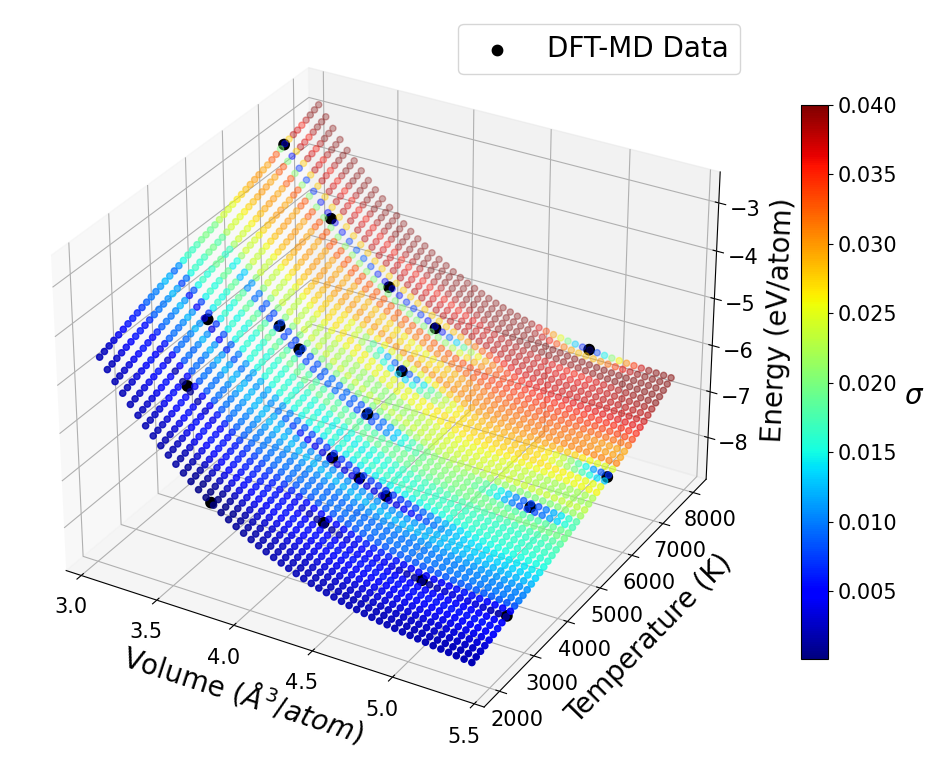

In [44]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(data[:,0], data[:,1], y2, alpha=1, marker="o", color="k", linewidths=4, label="Data")
p0 = ax.scatter(X_testP[:,0], X_testP[:,1], meanE ,c=stdE, cmap=plt.cm.jet, vmax=0.04)
matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
ax.set_xlabel(r'Volume ($\AA^{3}/atom$)', fontsize=20, labelpad=8 )
ax.set_ylabel('Temperature (K)', fontsize=20, labelpad=12)
ax.set_zlabel('Energy (eV/atom)',fontsize=20, labelpad=8)
ax.legend(['DFT-MD Data'], loc='upper right', fontsize =20)
cbar = fig.colorbar(p0, ax=ax, shrink = 0.6)
cbar.set_label(r'$\sigma$', rotation=0, fontsize=20, labelpad=12)
cbar.ax.tick_params(labelsize=15)
plt.show()

In [45]:
t = np.linspace(1,2500,2500, dtype=int)

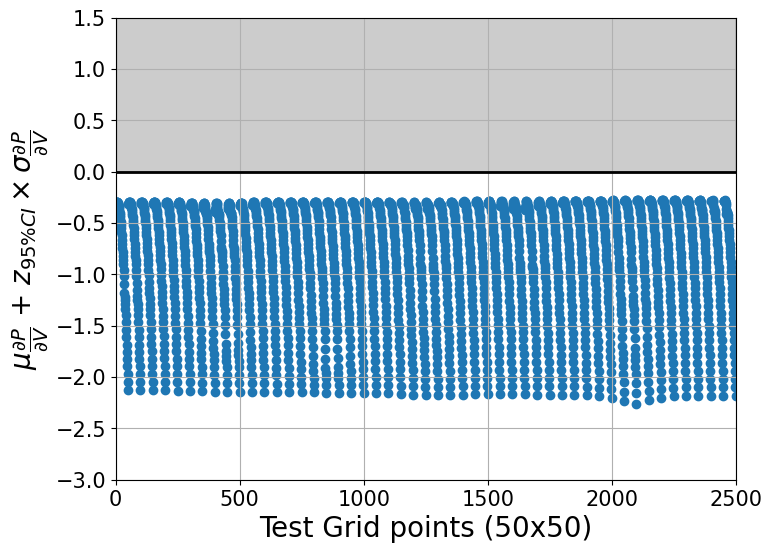

In [46]:
plt.figure(figsize=(8,6))
plt.scatter(t,consP)
plt.axhline(y=0, color ='k', linewidth =2)
plt.ylabel(r'$\mu_{\dfrac{\partial P}{\partial V}}$ $+$ $z_{95\% CI} \times \sigma_{\dfrac{\partial P}{\partial V}}$', fontsize = 20)
plt.xlabel('Test Grid points (50x50)', fontsize = 20)
plt.xlim((0,2500))
plt.ylim((-3,1.5))
plt.tick_params(labelsize=15)
plt.fill_between(t, y1=0, y2 = 1.5, color='black', alpha=.2)
plt.grid()

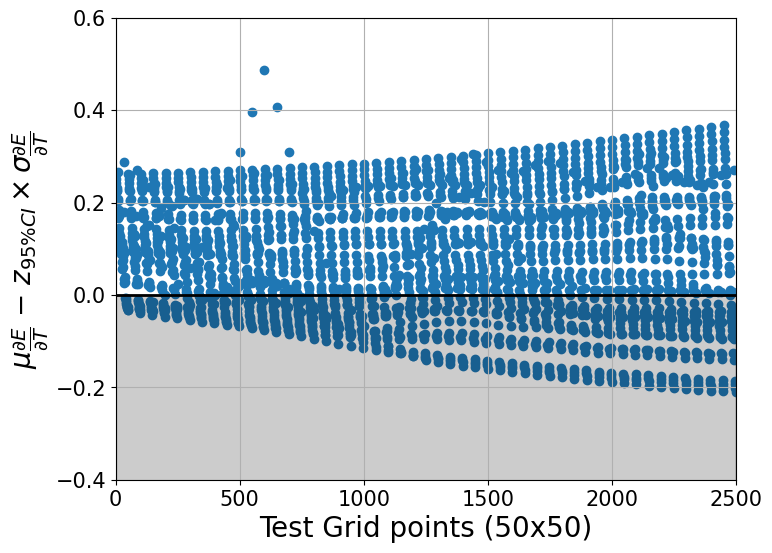

In [47]:
plt.figure(figsize=(8,6))
plt.scatter(t, consE)
plt.axhline(y=0, color ='k', linewidth =2)
plt.ylabel(r'$\mu_{\dfrac{\partial E}{\partial T}}$ $-$ $z_{95\% CI} \times \sigma_{\dfrac{\partial E}{\partial T}}$', fontsize = 20)
plt.xlabel('Test Grid points (50x50)', fontsize = 20)
plt.xlim((0,2500))
plt.ylim((-0.40,0.6))
plt.tick_params( labelsize=15)
plt.fill_between(t, y1=0, y2 = -0.6, color='black', alpha=.2)
plt.grid()